# HW03 Problem 2 — Fashion MNIST Image Classifier in PyTorch

This notebook puts together the five scripts from Problem 1
(`01_data_loading.py` through `05_evaluate.py`), in the same order, as one
notebook you can run from top to bottom. It follows the "Building an Image
Classifier with PyTorch" section of chapter 10 of *Hands-On Machine Learning
with Scikit-Learn and PyTorch* (Géron, 2025).

**Changes from the scripts:**
- **No `importlib` imports.** Every definition lives in this notebook, so the
  `importlib.import_module(...)` calls that loaded `01_data_loading.py`,
  `02_model.py` and `03_train.py` are gone. Later cells use names defined in
  earlier cells.
- **No `if __name__ == "__main__":` guards.** The code that sat under each
  guard is unindented into its own cell so it runs when the cell runs.
- **The plot also shows inline.** It is still saved to `accuracy.png`, and
  `plt.show()` is added so it appears in the notebook.

## 1. Data loading (`01_data_loading.py`)

Pick the best available device (CUDA, then Apple Silicon MPS, then CPU).
Download Fashion MNIST with torchvision and turn each image into a float32
tensor with pixel values between 0 and 1. Split the 60,000 training images
into 55,000 for training and 5,000 for validation, keeping the 10,000-image
test set separate. Build DataLoaders with batch size 32. Only the training
loader shuffles. Seeding with `torch.manual_seed(42)` makes the split and the
shuffling repeatable.

In [1]:
import torch
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# Convert PIL images to float32 tensors scaled to [0, 1]
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

Check the device, split sizes, batch shapes and class names:

In [2]:
print(f"Device: {device}")
print(f"Train: {len(train_data):,}  Valid: {len(valid_data):,}  "
      f"Test: {len(test_data):,}")
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X: {tuple(X_batch.shape)} {X_batch.dtype}, "
      f"y: {tuple(y_batch.shape)} {y_batch.dtype}")
print(f"Classes: {train_and_valid_data.classes}")

Device: mps
Train: 55,000  Valid: 5,000  Test: 10,000
Batch X: (32, 1, 28, 28) torch.float32, y: (32,) torch.int64
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 2. Model (`02_model.py`)

`ImageClassifier` is a multilayer perceptron. It flattens each 1×28×28 image
into 784 inputs, passes them through two hidden layers with ReLU activations
(300 and then 100 units), and ends with an output layer of 10 logits, one per
class. There is no final softmax, because `nn.CrossEntropyLoss` applies
log-softmax itself.

In [3]:
import torch.nn as nn


class ImageClassifier(nn.Module):
    def __init__(self, n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                 n_classes=10):
        super().__init__()
        # Outputs raw logits: nn.CrossEntropyLoss applies softmax internally
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

Check the model on a dummy batch. It should output 32 × 10 logits and have
266,610 parameters, the same as the book:

In [4]:
torch.manual_seed(42)
model = ImageClassifier()
print(model)
X_dummy = torch.rand(32, 1, 28, 28)
print(f"Output shape: {tuple(model(X_dummy).shape)}")
n_params = sum(param.numel() for param in model.parameters())
print(f"Parameters: {n_params:,}")

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Output shape: (32, 10)
Parameters: 266,610


## 3. Training (`03_train.py`)

`evaluate_tm` computes a torchmetrics metric over a whole DataLoader with the
model in eval mode and gradients turned off. `train` runs the training loop.
Each epoch it adds the mean training loss, the training accuracy and the
validation accuracy to a `history` dictionary and prints all three.

In [5]:
import json

import torchmetrics


def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()


def train(model, optimizer, criterion, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train accuracy: {history['train_metrics'][-1]:.4f}, "
              f"valid accuracy: {history['valid_metrics'][-1]:.4f}")
    return history

Train a new model with plain SGD (lr = 0.1, no momentum) for 20 epochs, using
cross-entropy loss and multiclass accuracy. Then save the weights to
`image_classifier.pt` and the history to `history.json`, like the script does.

In [6]:
n_epochs = 20
learning_rate = 0.1

torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300,
                        n_hidden2=100, n_classes=10).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=10).to(device)

print(f"Training on {device}")
history = train(model, optimizer, xentropy, accuracy, train_loader,
                valid_loader, n_epochs)

torch.save(model.state_dict(), "image_classifier.pt")
with open("history.json", "w") as f:
    json.dump(history, f, indent=2)

Training on mps


Epoch 1/20, train loss: 0.6060, train accuracy: 0.7810, valid accuracy: 0.8426


Epoch 2/20, train loss: 0.4055, train accuracy: 0.8500, valid accuracy: 0.8424


Epoch 3/20, train loss: 0.3627, train accuracy: 0.8663, valid accuracy: 0.8512


Epoch 4/20, train loss: 0.3345, train accuracy: 0.8766, valid accuracy: 0.8650


...

Epoch 16/20, train loss: 0.2074, train accuracy: 0.9210, valid accuracy: 0.8820


Epoch 17/20, train loss: 0.2026, train accuracy: 0.9238, valid accuracy: 0.8852


Epoch 18/20, train loss: 0.1993, train accuracy: 0.9240, valid accuracy: 0.8900


Epoch 19/20, train loss: 0.1928, train accuracy: 0.9256, valid accuracy: 0.8816


Epoch 20/20, train loss: 0.1869, train accuracy: 0.9283, valid accuracy: 0.8826


## 4. Plotting accuracy (`04_plot_accuracy.py`)

Plot training and validation accuracy for each epoch, using the history saved
by the training step. Training accuracy is averaged over the epoch while the
weights are still changing, so, as in the book, the training curve is shifted
half an epoch left of the validation accuracy measured at the end of each
epoch. The figure is saved to `accuracy.png`.

Saved accuracy.png


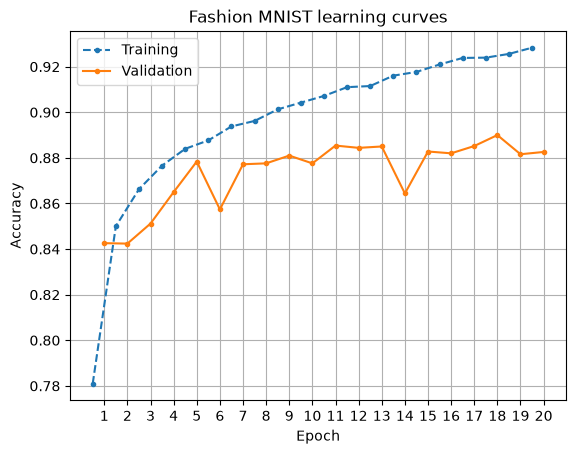

In [7]:
import matplotlib.pyplot as plt
import numpy as np

with open("history.json") as f:
    history = json.load(f)

n_epochs = len(history["train_metrics"])
epochs = np.arange(1, n_epochs + 1)

# Training accuracy is averaged over each epoch while the weights change, so
# like the book we shift it half an epoch left of the end-of-epoch
# validation accuracy
plt.plot(epochs - 0.5, history["train_metrics"], ".--", label="Training")
plt.plot(epochs, history["valid_metrics"], ".-", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.grid()
plt.title("Fashion MNIST learning curves")
plt.legend()
plt.savefig("accuracy.png", dpi=150, bbox_inches="tight")
print("Saved accuracy.png")
plt.show()

## 5. Test set evaluation (`05_evaluate.py`)

Build a new `ImageClassifier`, load the saved weights from
`image_classifier.pt`, and report accuracy on the 10,000 test images, which
weren't used for training or validation.

In [8]:
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
model.load_state_dict(torch.load("image_classifier.pt", map_location=device))

accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
test_accuracy = evaluate_tm(model, test_loader, accuracy).item()

print(f"Test set: {len(test_data):,} images")
print(f"Test accuracy: {test_accuracy:.4f}")

Test set: 10,000 images
Test accuracy: 0.8785
